In [1]:
# === Direct ARCO → Zarr for: u850, v850, z500, tcwv, msl ===
import os
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm
import dask.bag as db
import cartopy.crs as ccrs


import gcsfs
fs = gcsfs.GCSFileSystem(token='anon')  # public access

import xesmf as xe
from dask.distributed import LocalCluster,Client


cluster = LocalCluster(n_workers=6, memory_limit='32GiB')
client = Client(cluster)
client

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36087 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36087/status,
Dashboard: http://127.0.0.1:36087/status,Workers: 6
Total threads: 66,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35195,Workers: 0
Dashboard: http://127.0.0.1:36087/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33355,Total threads: 11
Dashboard: http://127.0.0.1:43779/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:43959,


In [2]:
import matplotlib.pyplot as plt


In [3]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"
ds = xr.open_zarr(zarr_out)

ds_variables = ds[['u850','v850','msl','z500','tcwv']]
ds_variables['tcwv'] = np.log(1+ds_variables['tcwv'])
ds_variables = ds_variables.to_array('var_name')

# dayofyearclim = ds_variables.rolling(time=30,center=True).mean().groupby('time.dayofyear').mean().rename('mean').load()
# dayofyearstd = ds_variables.rolling(time=30,center=True).construct('periods').groupby('time.dayofyear').std(['time','periods']).load()

# # dayofyearclim_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + dayofyearclim
# # dayofyearstd_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + dayofyearstd

# # ds_normed = (ds_variables - dayofyearclim_timeseries)/(dayofyearstd +1)

In [ ]:
import numpy as np
import xarray as xr
import xesmf as xe
from pyproj import CRS, Transformer

def make_npstereo_grid(nx=200, ny=200, extent_km=10050, lon0=0.0, gridspace=50000):
    """
    Make target grid in npstereo meters, with corresponding lon/lat for xESMF.
    Returns xr.Dataset with coords x (m), y (m), lon(y,x), lat(y,x).
    """
    # Projection
    npstereo = CRS.from_proj4(f"+proj=stere +lat_0=90 +lat_ts=90 +lon_0=0 +datum=WGS84 +units=m")
    geo  = CRS.from_epsg(4326)
    tfm = Transformer.from_crs(npstereo, geo, always_xy=True)

    extent_m = extent_km * 1000
    x = np.linspace(-extent_m, extent_m, nx)
    y = np.linspace(-extent_m, extent_m, ny)
    xx, yy = np.meshgrid(x, y)

    lon, lat = tfm.transform(xx, yy)

    ds_out = xr.Dataset(
        coords=dict(
            x=("x", x),
            y=("y", y),
            lon=(("y","x"), lon),
            lat=(("y","x"), lat),
        )
    )
    return ds_out

# --- Example usage ---

# Source data (lat/lon grid)
# da: DataArray (time, lat, lon)
# da = xr.open_dataset(...).z500

ds_out = make_npstereo_grid(nx=128, ny=128, extent_km=8000)

# Create regridder
regridder = xe.Regridder(ds_variables, ds_out, method="bilinear", periodic=True)

# Regrid
da_npstereo = regridder(ds_variables)

# Replace lon/lat with x/y coords in meters
da_npstereo = da_npstereo.assign_coords(x=ds_out.x, y=ds_out.y).drop_vars(["lon","lat"])



def rotate_east_north_to_npstereo_xy(u_e, v_n, longitude, longitude0_deg=0.0):
    """
    u_e, v_n: DataArrays on (latitude, longitude) or (y, x) with 'longitude' coord in degrees
    longitude: 2D longitudegitude array (same shape as u/v), degrees
    """
    # wrap (longitude - longitude0) to (-180, 180]
    dlongitude = (longitude - longitude0_deg + 180.0) % 360.0 - 180.0
    theta = np.deg2rad(dlongitude)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    u_x = cos_t * u_e - sin_t * v_n
    v_y = sin_t * u_e + cos_t * v_n
    return u_x, v_y

longitude2d, latitude2d = xr.broadcast(ds_variables['longitude'], ds_variables['latitude'])

# 1) Rotate to npstereo grid basis on the source grid
u_x_src, v_y_src = rotate_east_north_to_npstereo_xy(ds_variables.sel(var_name='u850'), ds_variables.sel(var_name='v850'), longitude2d, longitude0_deg=0.0)

ds_out = make_npstereo_grid(nx=128, ny=128, extent_km=9000, lon0=0.0)

# 3) Regrid each rotated component as a scalar
regridder = xe.Regridder(
    ds_variables.to_dataset('var_name')[['longitude','latitude']],
    ds_out, method="bilinear", periodic=True
)

ds_regridded = regridder(ds_variables).to_dataset('var_name')
u,v =rotate_east_north_to_npstereo_xy(ds_regridded.u850,ds_regridded.v850, ds_out.lon, )
ds_regridded['u850'] = u
ds_regridded['v850'] = v
ds_regridded = ds_regridded.to_array('var_name')


In [15]:
ds_regridded

<xarray.DataArray (var_name: 5, y: 128, x: 128, time: 31289)> Size: 21GB
dask.array<stack, shape=(5, 128, 128, 31289), dtype=float64, chunksize=(1, 128, 128, 256), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * x         (x) float64 1kB -9e+06 -8.858e+06 -8.717e+06 ... 8.858e+06 9e+06
  * y         (y) float64 1kB -9e+06 -8.858e+06 -8.717e+06 ... 8.858e+06 9e+06
    lon       (y, x) float64 131kB -45.0 -44.55 -44.08 ... 135.9 135.5 135.0
    lat       (y, x) float64 131kB -0.06494 0.3892 0.8432 ... 0.3892 -0.06494
  * var_name  (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
Attributes:
    regrid_method:  bilinear

In [14]:
ds_mean = ds_regridded.mean('time').load()
ds_std_local = ds_regridded.std('time').load()
ds_std_global = ds_regridded.std(['time','x','y']).load()
ds_normed = (ds_regridded - ds_mean)/ds_std_global
ds_normed

<xarray.DataArray (var_name: 5, y: 128, x: 128, time: 31289)> Size: 21GB
dask.array<truediv, shape=(5, 128, 128, 31289), dtype=float64, chunksize=(1, 128, 128, 256), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * x         (x) float64 1kB -9e+06 -8.858e+06 -8.717e+06 ... 8.858e+06 9e+06
  * y         (y) float64 1kB -9e+06 -8.858e+06 -8.717e+06 ... 8.858e+06 9e+06
    lon       (y, x) float64 131kB -45.0 -44.55 -44.08 ... 135.9 135.5 135.0
    lat       (y, x) float64 131kB -0.06494 0.3892 0.8432 ... 0.3892 -0.06494
  * var_name  (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'

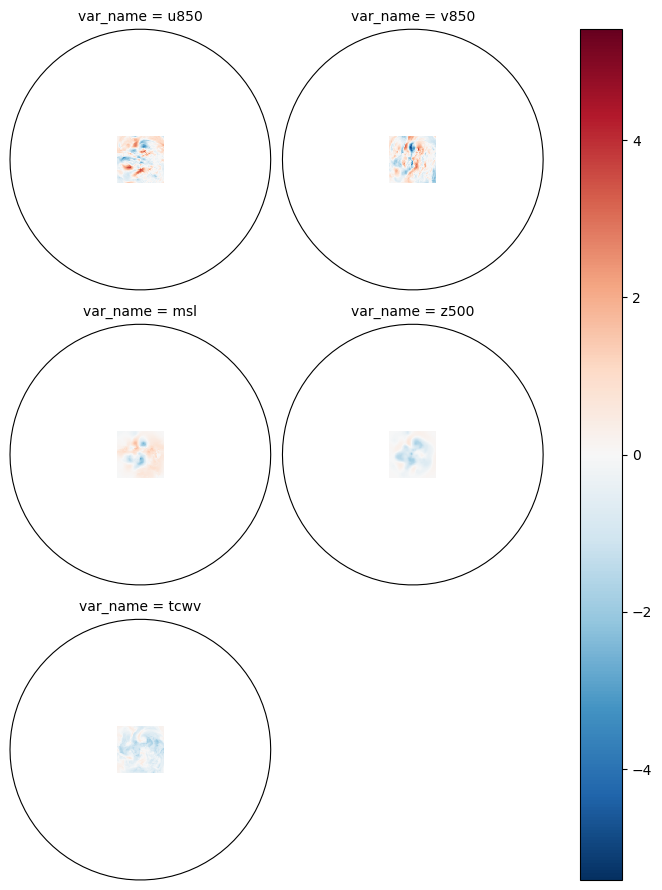

In [13]:
ds_ = ds_normed.sel(time='2007-01-09')#.assign_coords(var_name=['wind850_x','wind850_y','msl','z500'])
# ds_ = ds_/ds_.quantile(1,['x','y'])
plot = ds_.plot( col='var_name',col_wrap=2, subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90), aspect=1.1, x='x',y='y')
# for k, ax in enumerate(plot.axs.flatten()):
#     # dist.sel(time_of_event='2007-01-09').isel(timestep_past=k%7).plot.contour(ax=ax, levels=[1000], colors='C3',  transform=ccrs.NorthPolarStereo(0,90))
#     # data_plot.sel(var_name='msl').sel(time_of_event='2007-01-09').isel(timestep_past=k%7).plot.contour(levels=np.arange(96000,101000,500), transform=ccrs.NorthPolarStereo(0,90), colors='.4',linewidths=.3, ax=ax)
#     # ax.set_title(f'Timestep past = -{6-k%7}')
#     ax.coastlines(color='.3', lw=.5)


In [22]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe().set_index('track_id').sort_index()
cycs.sort_values('msl_prominence')

,date,segment_len,movement_speed,movement_direction,lon,lat,lon_raw,lat_raw,lon_maxlap,lat_maxlap,closed,msl,msl_prominence,msl_mingrad,msl_maxlap,cluster_id,bjerknes_id,stagnant_id,solo_cyc
track_id,,,,,,,,,,,,,,,,,,,
893145,2021-12-29 18:00:00,154966.995004,14.348796,4.756290,-178.894898,20.038900,179.340138,20.077232,176.878909,19.946997,False,101071.914072,25.000907,0.000195,4.528034e-06,0,0,0,1
180833,1987-11-09 03:00:00,26025.120738,2.409733,1.613771,2.636475,19.969914,1.862388,19.998479,1.174986,20.015604,True,101245.496532,25.001377,0.000000,1.375582e-08,0,0,0,1
692894,2012-07-27 00:00:00,101918.168420,9.436867,5.123329,-0.185799,20.975887,-0.321391,21.055796,-0.945767,20.019590,False,100697.631524,25.002122,0.000120,5.186627e-06,0,0,0,1
359193,1996-07-14 09:00:00,77366.560945,7.163570,4.371752,-1.450164,20.464039,-1.699075,20.273025,-1.576025,20.006556,True,100904.780617,25.002543,0.000000,4.295507e-06,3783,0,2442,0
406351,1998-11-06 21:00:00,NaN,NaN,NaN,-3.696726,19.914762,-3.349658,19.934851,-3.406784,19.931681,True,101324.169638,25.004466,0.000000,2.056404e-06,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
908092,2022-09-24 09:00:00,109322.921834,10.122493,6.141148,-61.041070,46.014371,-61.234912,46.024108,-61.369730,45.996723,True,94928.343634,1622.128433,0.000000,4.934071e-08,9619,5706,0,0
788450,2017-02-06 00:00:00,178316.393009,16.510777,0.493125,-30.066783,53.996066,-29.967224,54.041674,-30.074208,54.005358,True,93704.353589,1626.697091,0.000000,4.785951e-08,8361,4964,0,0
220895,1989-10-29 18:00:00,200186.400771,18.535778,0.684741,160.818941,43.367497,160.857368,43.439282,160.650521,43.458569,True,93189.776441,1664.862408,0.000000,5.052200e-08,2312,0,1499,0


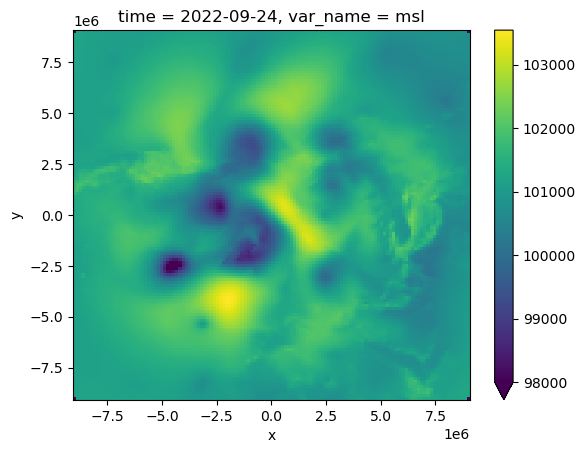

In [23]:
ds_regridded.sel(var_name='msl').sel(time='2022-09-24').plot(vmin=98000)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


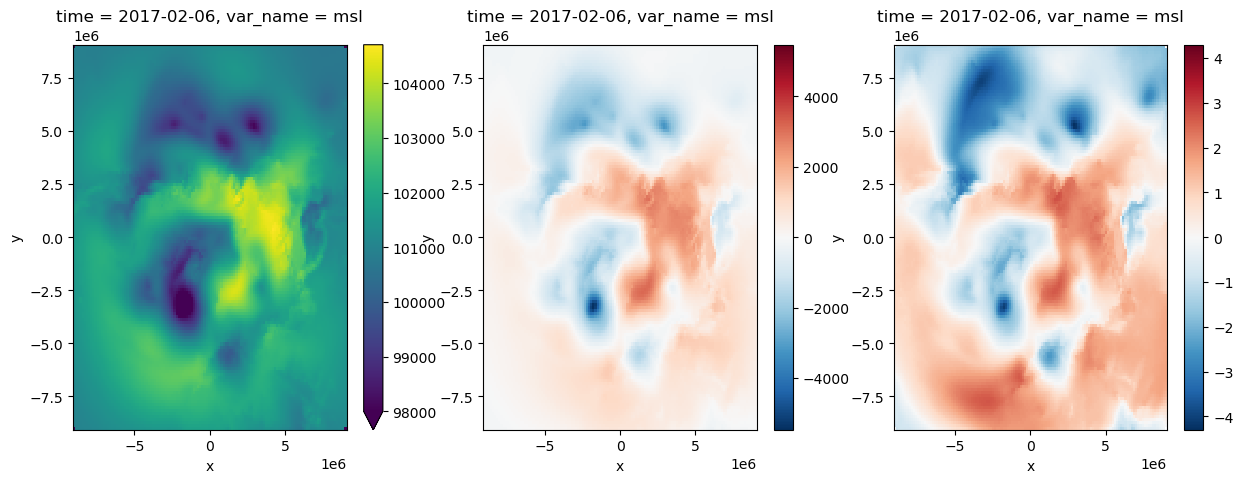

In [27]:
fig, axs = plt.subplots(1,3, figsize=(15,5))
time_test = '2017-02-06'
ds_regridded.sel(var_name='msl').sel(time=time_test).plot(vmin=98000, ax=axs[0])
(ds_regridded-ds_mean).sel(var_name='msl').sel(time=time_test).plot(ax=axs[1])
ds_normed.sel(var_name='msl').sel(time=time_test).plot(ax=axs[2])

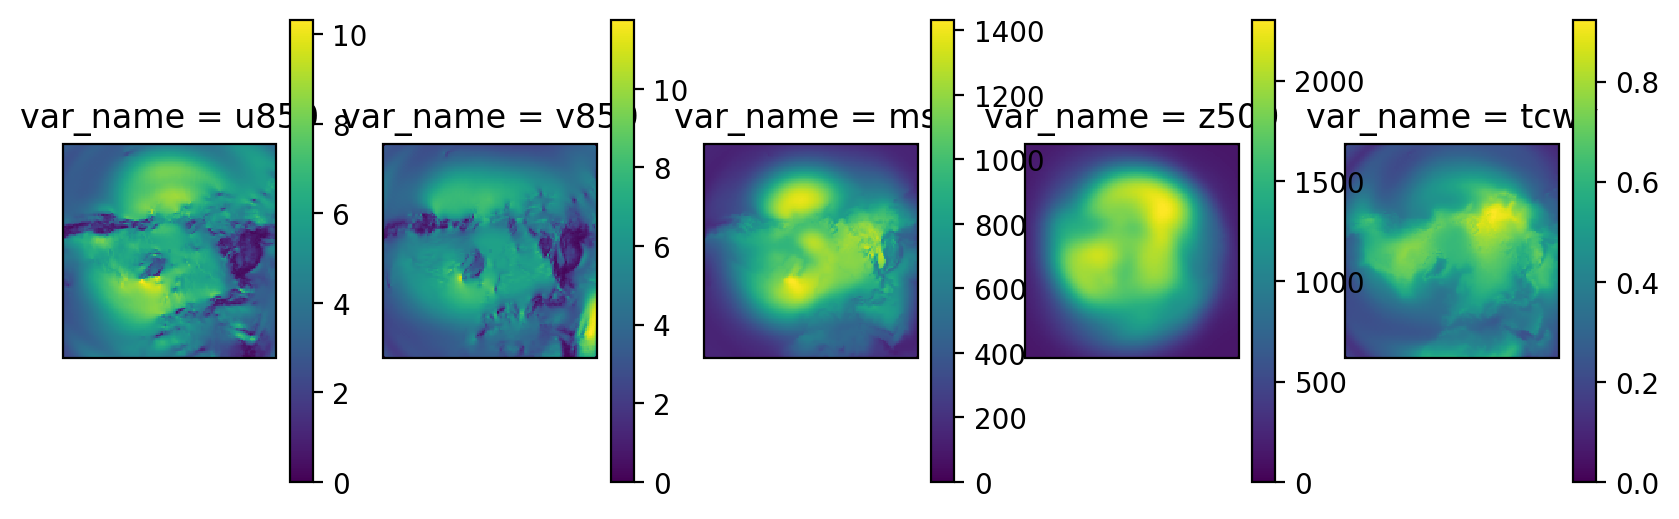

In [34]:
fig, axs = plt.subplots(1,5,figsize=(10,3),dpi=200, subplot_kw=dict(projection=ccrs.NorthPolarStereo(0,90)))

for k,ax in enumerate(axs.flatten()):
    ds_std_local.isel(var_name=k).plot(ax=ax, transform = ccrs.NorthPolarStereo(0,90))

In [35]:
ds_mean = ds_regridded.mean('time').load()
ds_std_local = ds_regridded.std('time').load()
ds_std_global = ds_regridded.std(['time','x','y']).load()
ds_normed = (ds_regridded - ds_mean)/ds_std_global

In [37]:
ds_out = xr.Dataset(dict(data_normed=ds_normed.fillna(0),
                         data_mean=ds_mean,
                         data_std_global=ds_std_global,
                         data_std_local = ds_std_local))

zarr_out_regrid = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024_equalarea.zarr"

chunks = {'time': 256}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {#'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks},
       #'data_mean': {'compressors': compressor, 'dtype': 'float32'},
       'data_std_local': {'compressors': compressor, 'dtype': 'float32'},
       'data_std_global': {'compressors': compressor, 'dtype': 'float32'},
       }

ds_out.chunk(dict(time=256)).astype(np.float32).to_zarr(
        zarr_out_regrid, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [69]:
ds_test = ds_regridded.sel(time='2005-02-18').to_dataset('var_name').load()
# ds_test['u850'] = ds_test['u850']*0
ds_test = ds_test.to_array('var_name')
u,v =rotate_east_north_to_npstereo_xy(ds_test.sel(var_name='u850'),ds_test.sel(var_name='v850' ), ds_out.lon, )
ds_test = xr.concat([ds_test, u.assign_coords(var_name='x850'), v.assign_coords(var_name='y850')], dim='var_name')

/tmp/ipykernel_247623/3327043839.py:2: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in plot.axes.flatten():


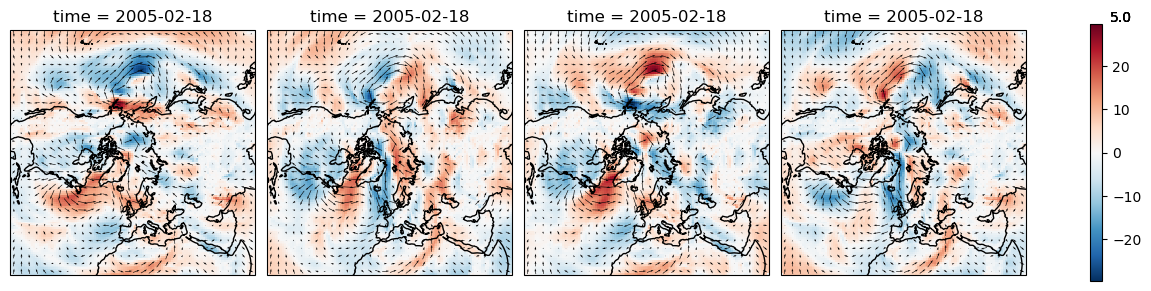

In [70]:
plot = ds_test.sel(var_name=['u850','v850', 'x850','y850']).plot(transform=ccrs.NorthPolarStereo(0,90), subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), col='var_name')
for ax in plot.axes.flatten():
    ax.coastlines()
    ds_test.to_dataset('var_name').coarsen(x=4, y=4).mean().plot.quiver(x='x',y='y', u='x850', v='y850', ax=ax)

In [39]:
src = ccrs.PlateCarree()
tgt = ccrs.NorthPolarStereo(central_longitude=0, true_scale_latitude=70)
ds_test = ds_regridded.sel(time='1993-01-11', var_name=['u850','v850'])
# After regridding u_e, v_n to target lon/lat:
Ux, Vy = tgt.transform_vectors(src, ds_out.lon.values, ds_out.lat.values, ds_test.sel(var_name='u850').values, ds_test.sel(var_name='v850').values)

In [43]:
Vy

array([[ 2.22466342,  2.71705777,  3.4359176 , ..., -4.55801055,
        -4.91237161, -5.43300229],
       [ 2.20720903,  2.70530236,  3.32787464, ..., -3.96940055,
        -4.29595897, -4.95215298],
       [ 1.69565851,  2.13036273,  2.26959935, ..., -3.44674142,
        -3.99812785, -4.61850503],
       ...,
       [ 4.72282918,  4.1395807 ,  3.63384478, ..., -4.82680693,
        -4.53248375, -4.28215249],
       [ 5.04558517,  4.45296361,  3.84790543, ..., -4.47937058,
        -4.28825879, -4.05082054],
       [ 5.24075389,  4.88030381,  4.2514812 , ..., -4.18611639,
        -4.01789239, -3.75792108]], shape=(128, 128))

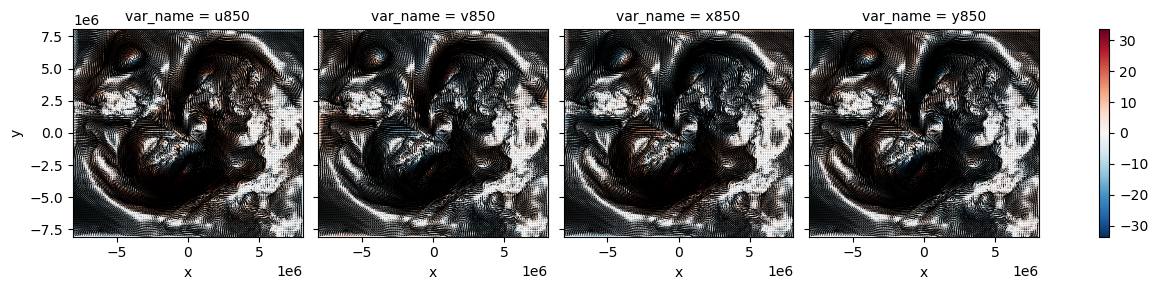

In [44]:
ds_test = ds_regridded.sel(time='1993-01-11', var_name=['u850','v850','x850','y850'])
plot = ds_test.plot(col='var_name')
for ax in plot.axs.flatten():
    ax.quiver(ds_test.x, ds_test.y, Ux, Vy, scale=300 )
    # ds_test.to_dataset('var_name').coarsen(x=8,y=8, ).mean().plot.quiver(ax=ax,x='x',y='y', u='y850',v='x850', scale=300)



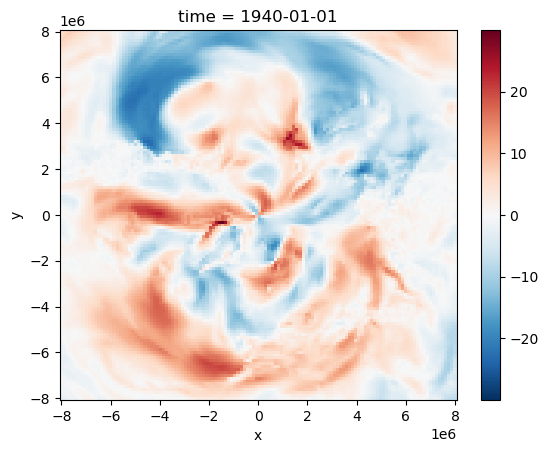

In [7]:
u_x_tgt.isel(time=0).plot()

/tmp/ipykernel_245677/1010426425.py:2: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in plot.axes.flatten():


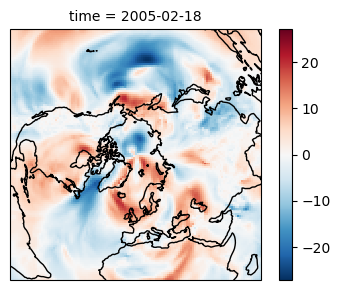

In [11]:
plot = u_x_tgt.sel(time=['2005-02-18']).plot(transform=ccrs.LambertAzimuthalEqualArea(0,90), subplot_kws=dict(projection=ccrs.LambertAzimuthalEqualArea(0,90)), col='time')
for ax in plot.axes.flatten():
    ax.coastlines()

In [ ]:
# ds_mean = da_laea.mean('time').load()
# ds_std = da_laea.std('time').load()
# ds_normed = (da_laea - ds_mean)/ds_std

In [93]:
u_e_tgt

<xarray.DataArray (time: 31289, y: 128, x: 128)> Size: 2GB
dask.array<astype, shape=(31289, 128, 128), dtype=float32, chunksize=(256, 128, 128), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
    var_name  <U4 16B 'u850'
  * x         (x) float64 1kB -8e+06 -7.874e+06 -7.748e+06 ... 7.874e+06 8e+06
  * y         (y) float64 1kB -8e+06 -7.874e+06 -7.748e+06 ... 7.874e+06 8e+06
    lon       (y, x) float64 131kB -45.0 -44.55 -44.08 ... 135.9 135.5 135.0
    lat       (y, x) float64 131kB -35.34 -33.63 -31.98 ... -31.98 -33.63 -35.34
Attributes:
    regrid_method:  bilinear

In [ ]:
longitude0 = 0.0
src_crs = ccrs.PlateCarree()
tgt_crs = ccrs.LambertAzimuthalEqualArea(central_longitude=longitude0, central_latitude=90)

# 1) Build your LAEA target grid (as you already do) -> ds_out with longitude(y,x), latitude(y,x)
ds_out = make_laea_grid(nx=128, ny=128, extent_km=8000, lon0=longitude0)

# 2) Regrid u_east and v_north to the target points as scalars
regridder = xe.Regridder(ds_variables, ds_out, method="bilinear", periodic=True)
u_e_tgt = regridder(ds_variables.sel(var_name='u850'))   # eastward (m/s) on ds_out grid
v_n_tgt = regridder(ds_variables.sel(var_name='v850'))   # northward (m/s) on ds_out grid

# 3) Transform vectors from PlatitudeeCarree to LAEA at those target longitude/latitude
Ux, Vy = tgt_crs.transform_vectors(
    src_crs,
    u_e_tgt['lon'].values, u_e_tgt['lat'].values,
    u_e_tgt.values, v_n_tgt.values
)

# 4) Put back into DataArrays on (y,x)
u_x = xr.DataArray(Ux, coords={'y': ds_out.y, 'x': ds_out.x}, dims=('y','x'))
v_y = xr.DataArray(Vy, coords={'y': ds_out.y, 'x': ds_out.x}, dims=('y','x'))


In [97]:
u_e_tgt.shape

(31289, 128, 128)

In [ ]:

# 3) Transform vectors from PlatitudeeCarree to LAEA at those target longitude/latitude
Ux, Vy = tgt_crs.transform_vectors(
    src_crs,
    u_e_tgt['lon'].values, u_e_tgt['lat'].values,
    u_e_tgt.sel(time='1993-01-11').values, v_n_tgt.sel(time='1993-01-11').values
)

# 4) Put back into DataArrays on (y,x)
u_x = xr.DataArray(Ux, coords={'y': ds_out.y, 'x': ds_out.x}, dims=('y','x'))
v_y = xr.DataArray(Vy, coords={'y': ds_out.y, 'x': ds_out.x}, dims=('y','x'))


In [59]:
u_x_tgt

<xarray.DataArray (time: 31289, y: 128, x: 128)> Size: 4GB
dask.array<sum-aggregate, shape=(31289, 128, 128), dtype=float64, chunksize=(256, 128, 128), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
    lon      (y, x) float64 131kB -45.0 -44.55 -44.08 ... 135.9 135.5 135.0
    lat      (y, x) float64 131kB -35.34 -33.63 -31.98 ... -31.98 -33.63 -35.34
  * x        (x) float64 1kB -8e+06 -7.874e+06 -7.748e+06 ... 7.874e+06 8e+06
  * y        (y) float64 1kB -8e+06 -7.874e+06 -7.748e+06 ... 7.874e+06 8e+06
Attributes:
    regrid_method:  bilinear

In [17]:
u_x, u_y = rotate_to_grid_uv(da_laea.isel(time=0).sel(var_name='u850'), da_laea.isel(time=0).sel(var_name='v850'), ds_out.lon)

In [100]:
ds_test = da_laea.sel(time='1993-01-11').sel(var_name=['u850','v850'])
ds_test = xr.concat([ds_test, u_x.assign_coords(var_name='x850'), v_y.assign_coords(var_name='y850')], dim='var_name')

In [80]:
ds_variables.sel(var_name='msl').min(['longitude','latitude']).idxmin().load()

<xarray.DataArray 'time' ()> Size: 8B
array('1993-01-11T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    var_name  <U3 12B 'msl'

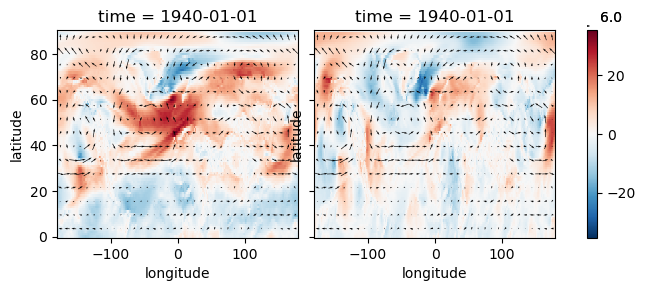

In [102]:
plot = ds_variables.sel(var_name=['u850','v850']).sel(time='1993-01-11').plot(col='var_name')
for ax in plot.axs.flatten():
    ds_variables.to_dataset('var_name').isel(time=0).coarsen(longitude=10,latitude=6, boundary='trim').mean().plot.quiver(ax=ax,x='longitude',y='latitude', u='u850',v='v850', scale=500)



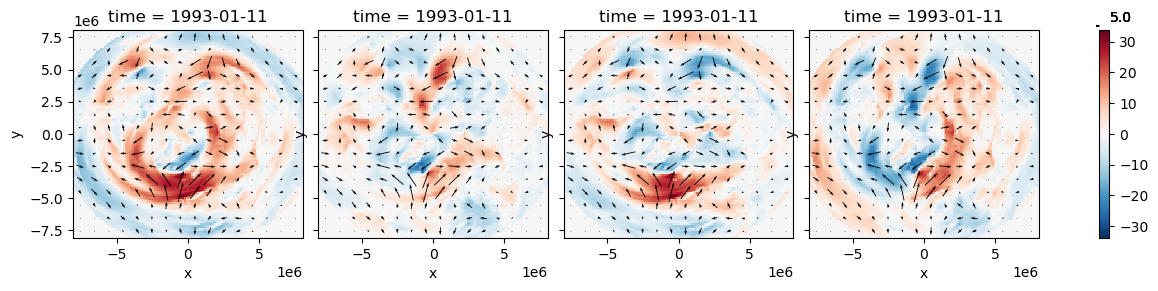

In [ ]:
plot = ds_test.plot(col='var_name')
for ax in plot.axs.flatten():
    ds_test.to_dataset('var_name').coarsen(x=8,y=8, ).mean().plot.quiver(ax=ax,x='x',y='y', u='y850',v='x850', scale=300)



In [5]:
ds_out = xr.Dataset(dict(data_normed=ds_normed.fillna(0),
                         data_mean=ds_mean,
                         data_std=ds_std))

zarr_out_regrid = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024_equalarea.zarr"

chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks},
       'data_mean': {'compressors': compressor, 'dtype': 'float32'},
       'data_std': {'compressors': compressor, 'dtype': 'float32'},
       }

ds_out.chunk(dict(time=256)).astype(np.float32).to_zarr(
        zarr_out_regrid, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 10.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-pac

In [6]:
ds = xr.open_zarr('/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024_equalarea.zarr')

/tmp/ipykernel_173133/912292240.py:2: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in plot.axes.flatten():


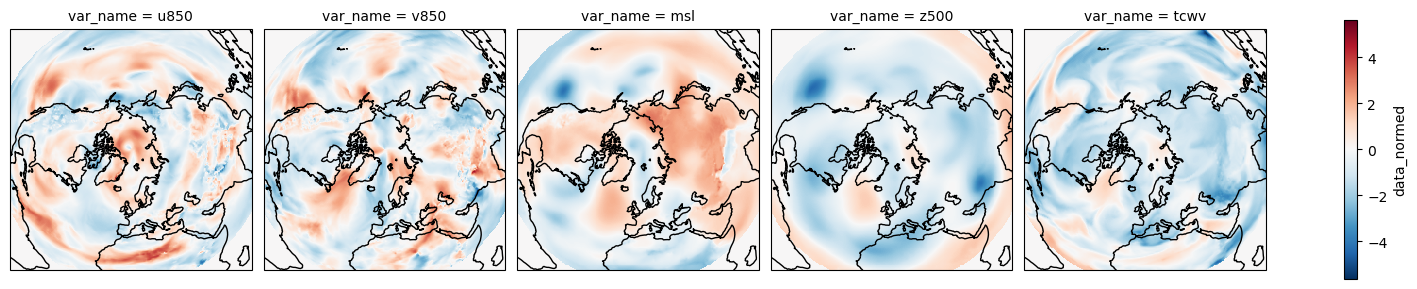

In [8]:
plot = ds.data_normed.fillna(1000).sel(time='2005-02-18').plot(transform=ccrs.LambertAzimuthalEqualArea(0,90), subplot_kws=dict(projection=ccrs.LambertAzimuthalEqualArea(0,90)), col='var_name')
for ax in plot.axes.flatten():
    ax.coastlines()

In [24]:
xr.open_zarr(zarr_out)

<xarray.Dataset> Size: 41GB
Dimensions:         (time: 31289, latitude: 91, longitude: 360, var_name: 5,
                     dayofyear: 366)
Coordinates:
  * latitude        (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 2.0 1.0 0.0
  * longitude       (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time            (time) datetime64[ns] 250kB 1940-01-01 ... 2025-08-30
  * var_name        (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
  * dayofyear       (dayofyear) int64 3kB 1 2 3 4 5 6 ... 362 363 364 365 366
Data variables:
    u850            (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    tcwv            (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    dayofyear_mean  (var_name, dayofyear, latitude, longitude) float32 240MB dask.array<chunksize=(2, 92, 23, 90), meta=np.ndarray>
    v850            (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    z500            (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    msl             (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    dayofyear_std   (var_name, dayofyear, latitude, longitude) float32 240MB dask.array<chunksize=(2, 92, 23, 90), meta=np.ndarray>
    data_normed     (var_name, time, latitude, longitude) float32 21GB dask.array<chunksize=(1, 256, 23, 90), meta=np.ndarray>
    data_mean       (var_name, latitude, longitude) float32 655kB dask.array<chunksize=(3, 46, 360), meta=np.ndarray>
    data_std        (var_name, latitude, longitude) float32 655kB dask.array<chunksize=(3, 46, 360), meta=np.ndarray>

In [ ]:

ds_out = make_laea_grid(nx=400, ny=400, extent_km=10050)

# Create regridder
regridder = xe.Regridder(da, ds_out, method="bilinear", periodic=True)

# Regrid
da_laea = regridder(da)

# Replace lon/lat with x/y coords in meters
da_laea = da_laea.assign_coords(x=ds_out.x, y=ds_out.y).drop_vars(["lon","lat"])

In [ ]:
import xarray as xr
import rioxarray # This is needed to access the .rio accessor
import rasterio as rio
import numpy as np

# --- 1. Create Sample Data ---
# Create a sample DataArray on a global lat/lon grid
lon = np.arange(-180, 180, 20)
lat = np.arange(0, 90, 20)
data = np.random.rand(len(lat), len(lon))

# Create the xarray DataArray
# Note: xarray expects coords in (y, x) order, so (lat, lon)
ds_variables.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=True)
target_crs_laea = "+proj=laea +lat_0=90 +lon_0=0 +x_0=4321000 +y_0=3210000 +ellps=GRS80 +units=m +no_defs"
ds_variables.rio.write_crs("EPSG:4326", inplace=True)
all_regridded = []
for var in ds_variables.var_name:
    print(var.values)
    raw_data = ds_variables.sel(var_name=var)
    regridded_data = raw_data.rio.reproject(target_crs_laea, 
                                            resolution=100_000,
                                            resampling=rio.enums.Resampling.bilinear)
    all_regridded.append(regridded_data.assign_coords(var_name=var))
ds_regridded = xr.concat(all_regridded, dim='var_name')
# The new coordinates are 'x' and 'y' in meters, not degrees.
# The data is now on the Lambert Azimuthal grid.

u850
v850


In [15]:
ds_mean = ds_regridded.mean('time').load()
ds_std = ds_regridded.std('time').load()
ds_normed = (ds_regridded - ds_mean)/ds_std

In [9]:
map_projection = ccrs.Projection(regridded_data.rio.crs)

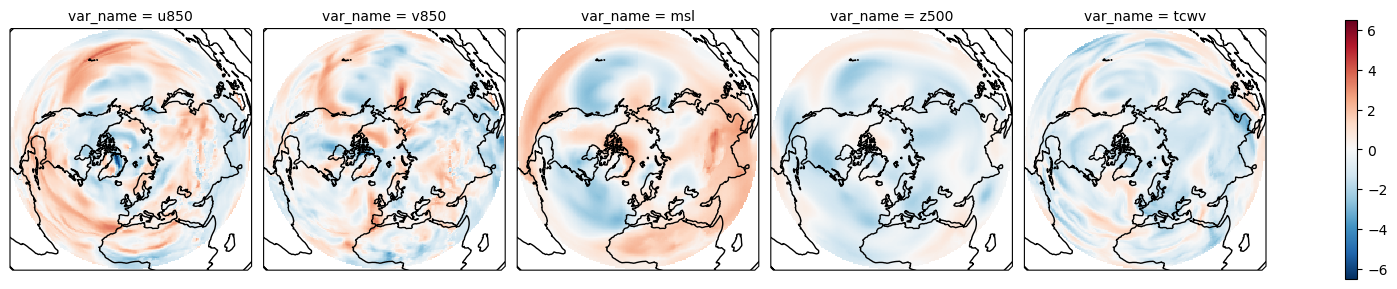

In [16]:
plot = ds_normed.isel(time=0).plot(transform=map_projection, subplot_kws=dict(projection=ccrs.LambertAzimuthalEqualArea(0,90)), col='var_name')
for ax in plot.axs.flatten():
    ax.coastlines()

In [128]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 1. Define source data (example)
ds_in = ds_variables.isel(time=0) # Replace with your actual data

# 2. Create target grid for xesmf (e.g., a finer Platitudee Carree grid)
longitude_out = np.linspace(ds_in['longitude'].min(), ds_in['longitude'].max(), 200)
latitude_out = np.linspace(ds_in['latitude'].min(), ds_in['latitude'].max(), 100)
ds_out = xr.Dataset(
    coords={'longitude': longitude_out, 'latitude': latitude_out}
)

# 3. Perform regridding with xesmf
regridder = xe.Regridder(ds_in, ds_out, method='bilinear')
ds_regridded = regridder(ds_in['Tair']) # Regrid a specific variable

# 4. Plot with cartopy
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlatitudeeCarree()) # Or your desired projection

ds_regridded.plot.pcolormesh(ax=ax, transform=ccrs.PlatitudeeCarree(), cmap='viridis') # Use transform=ccrs.PlatitudeeCarree() if your regridded data is on a Platitudee Carree grid

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.title('Regridded Data on Cartopy Projection')
plt.show()

ValueError: dimensions () must have the same length as the number of data dimensions, ndim=1

In [ ]:
ds_mean = ds_variables.mean('time').load()
ds_std = ds_variables.std('time').load()
from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_mean': {'compressors': compressor, 'dtype': 'float32'},
       'data_std': {'compressors': compressor, 'dtype': 'float32'}}

xr.Dataset(dict(data_std=ds_std, data_mean=ds_mean)).astype(np.float32).to_zarr(
        zarr_out, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [ ]:
import numpy as np
import xarray as xr
from pyproj import CRS, Transformer

def make_laea_nh_ds_out(nx=300, ny=300, extent_km=10050, lon0=0.0):
    """
    Build a lon/lat xarray.Dataset describing a Lambert Azimuthal Equal Area grid
    centered at the North Pole (lat0=90) with radius ~ extent_km.
    
    Parameters
    ----------
    nx, ny : int
        Number of grid points in x (east-west) and y (north-south).
    extent_km : float
        Half-width of the grid in kilometers from the pole in projection meters.
        ~10,007 km reaches the equator; use a bit more (e.g., 10,050) to be safe.
    lon0 : float
        Central longitude of the projection (degrees). 0 is fine for most use.

    Returns
    -------
    ds_out : xr.Dataset
        Dataset with 2D variables 'lon' and 'lat' on dims ('y','x'), for xESMF.
        Points south of the equator are set to NaN so you can mask them out.
    """
    # 1) Define CRS: LAEA centered at the North Pole
    laea = CRS.from_proj4(f"+proj=laea +lat_0=90 +lon_0={lon0} +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")
    geo  = CRS.from_epsg(4326)  # WGS84 lon/lat

    # 2) Build a regular grid in projection meters
    extent_m = extent_km * 1000.0
    x = np.linspace(-extent_m, extent_m, nx)
    y = np.linspace(-extent_m, extent_m, ny)
    xx, yy = np.meshgrid(x, y)

    # 3) Transform LAEA (x,y) -> lon/lat with pyproj (robust & fast)
    #    always_xy=True => inputs are (x, y); outputs are (lon, lat)
    tfm = Transformer.from_crs(laea, geo, always_xy=True)
    lon, lat = tfm.transform(xx, yy)

    # 4) Mask anything south of the equator (outside the NH in this projection)
    lat = np.where(lat >= 0.0, lat, np.nan)
    # Normalize lon into [-180, 180] for sanity
    lon = ((lon + 180) % 360) - 180

    # 5) Package as ds_out for xESMF
    ds_out = xr.Dataset(
        data_vars=dict(
            lon=(["y", "x"], lon.astype(np.float64)),
            lat=(["y", "x"], lat.astype(np.float64)),
        ),
        coords=dict(
            y=np.arange(ny, dtype=np.int32),
            x=np.arange(nx, dtype=np.int32),
        ),
        attrs=dict(
            grid="LAEA_NH",
            projection="Lambert Azimuthal Equal Area (lat0=90)",
            central_longitude=float(lon0),
            extent_km=float(extent_km),
        ),
    )
    return ds_out


In [140]:
map_projection = ccrs.Projection(regridded_data.rio.crs)

In [121]:
ds_out = make_laea_nh_ds_out(nx=400, ny=400, extent_km=5050, lon0=0)

In [123]:
regridder = xe.Regridder(ds_variables, ds_out, method="bilinear", periodic=True)
da_laea = regridder(ds_variables).assign_coords(
    lon=(("y","x"), ds_out["lon"].values),
    lat=(("y","x"), ds_out["lat"].values),
)   # dims: (time, y, x)
mask = xr.DataArray(np.isfinite(ds_out.lat), dims=("y","x"))
da_laea = da_laea.where(mask)

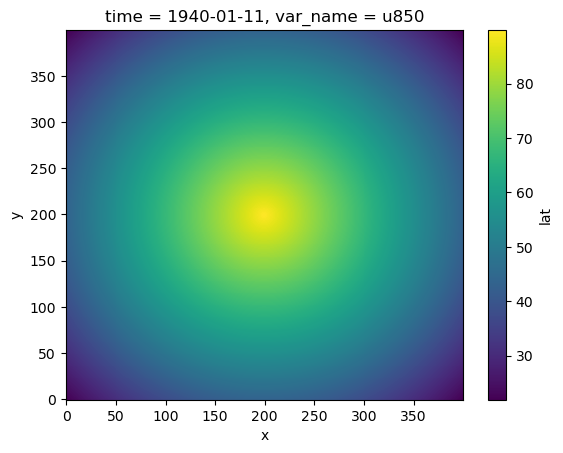

In [125]:
field.lat.plot()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 14.88 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


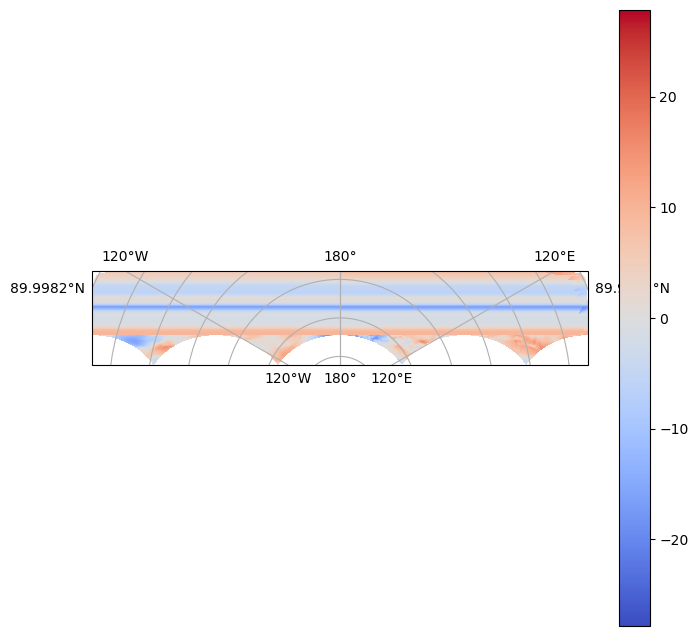

In [124]:


field = da_laea.sel(var_name='u850').isel(time=10)

proj = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)
fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(8,8))

field.plot.pcolormesh(
    x='lon', y='lat',
    ax=ax,
    transform=proj,  # <-- works here
    cmap="coolwarm",
    add_colorbar=True,
    add_labels=False
)

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.show()


In [117]:
Zmask = np.where(field['lat'].values >= 0, field.values, np.nan)

ax.pcolormesh(field['lon'], field['lat'], Zmask,
              transform=ccrs.PlateCarree(), shading='auto')

ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

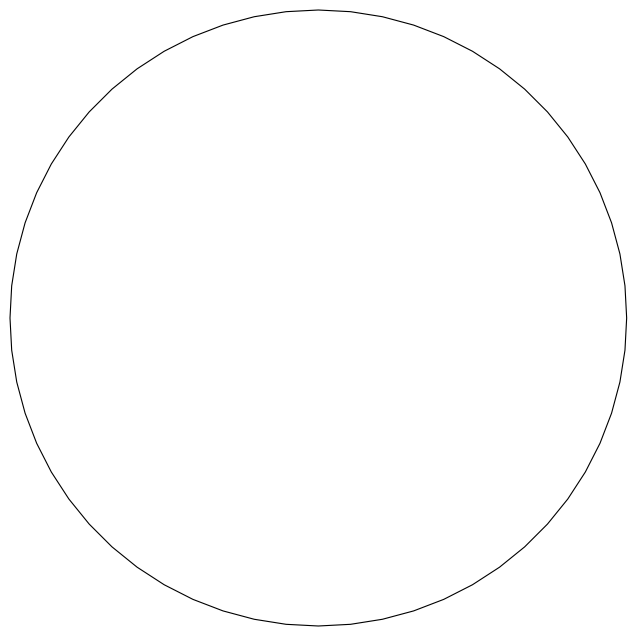

In [113]:
proj = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)

fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(8,8))
mesh = ax.pcolormesh(
    field["lon"], field["lat"], field.values,
    transform=ccrs.PlateCarree(),   # source CRS of lon/lat
)
ax.coastlines()
ax.gridlines(draw_labels=True)
fig.colorbar(mesh, ax=ax, orientation="horizontal")
plt.show()

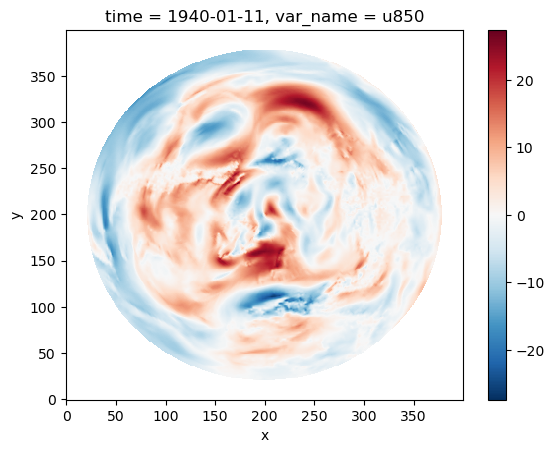

In [106]:
da_laea.sel(var_name='u850').isel(time=10).plot()

In [71]:
ds_mean = ds_regridded.mean('time').load()
ds_std = ds_regridded.std('time').load()

In [79]:
# ds_mean.sel(var_name=['u850','v850']).plot(col='var_name', subplot_kws=dict(projection=ccrs.PlateCarree()), transform=laea, x='longitude', y='latitude')

In [72]:
ds_normed = (ds_regridded - ds_mean)/ds_std

In [61]:
target_grid

<xarray.Dataset> Size: 1MB
Dimensions:  (y: 256, x: 256)
Coordinates:
  * y        (y) int64 2kB 0 1 2 3 4 5 6 7 8 ... 248 249 250 251 252 253 254 255
  * x        (x) int64 2kB 0 1 2 3 4 5 6 7 8 ... 248 249 250 251 252 253 254 255
Data variables:
    lat      (y, x) float64 524kB -35.34 -34.48 -33.64 ... -33.64 -34.48 -35.34
    lon      (y, x) float64 524kB -45.0 -44.77 -44.55 ... 135.5 135.2 135.0

In [69]:
ds_regridded

<xarray.DataArray (var_name: 5, time: 31289, y: 256, x: 256)> Size: 41GB
dask.array<astype, shape=(5, 31289, 256, 256), dtype=float32, chunksize=(1, 256, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
  * y          (y) int64 2kB 0 1 2 3 4 5 6 7 ... 248 249 250 251 252 253 254 255
  * x          (x) int64 2kB 0 1 2 3 4 5 6 7 ... 248 249 250 251 252 253 254 255
    longitude  (y, x) float64 524kB -45.0 -44.77 -44.55 ... 135.5 135.2 135.0
    latitude   (y, x) float64 524kB -35.34 -34.48 -33.64 ... -34.48 -35.34
Attributes:
    regrid_method:  bilinear

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


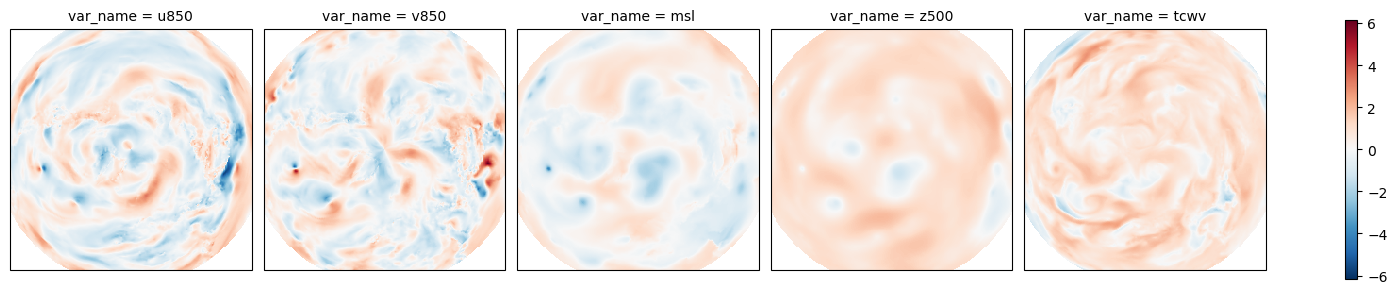

In [86]:
ds_normed.sel(time='2005-09-14').plot(col='var_name', subplot_kws=dict(projection=laea), transform=laea,)

In [11]:
ds_normed=(ds_variables-ds_mean)/ds_std
# ds_normed.chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
#         zarr_out, mode='a', #encoding=enc,
#         write_empty_chunks=False  # don't materialize empties
#     )

In [22]:
ds_variables

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 21GB
dask.array<stack, shape=(5, 31289, 91, 360), dtype=float32, chunksize=(1, 256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'

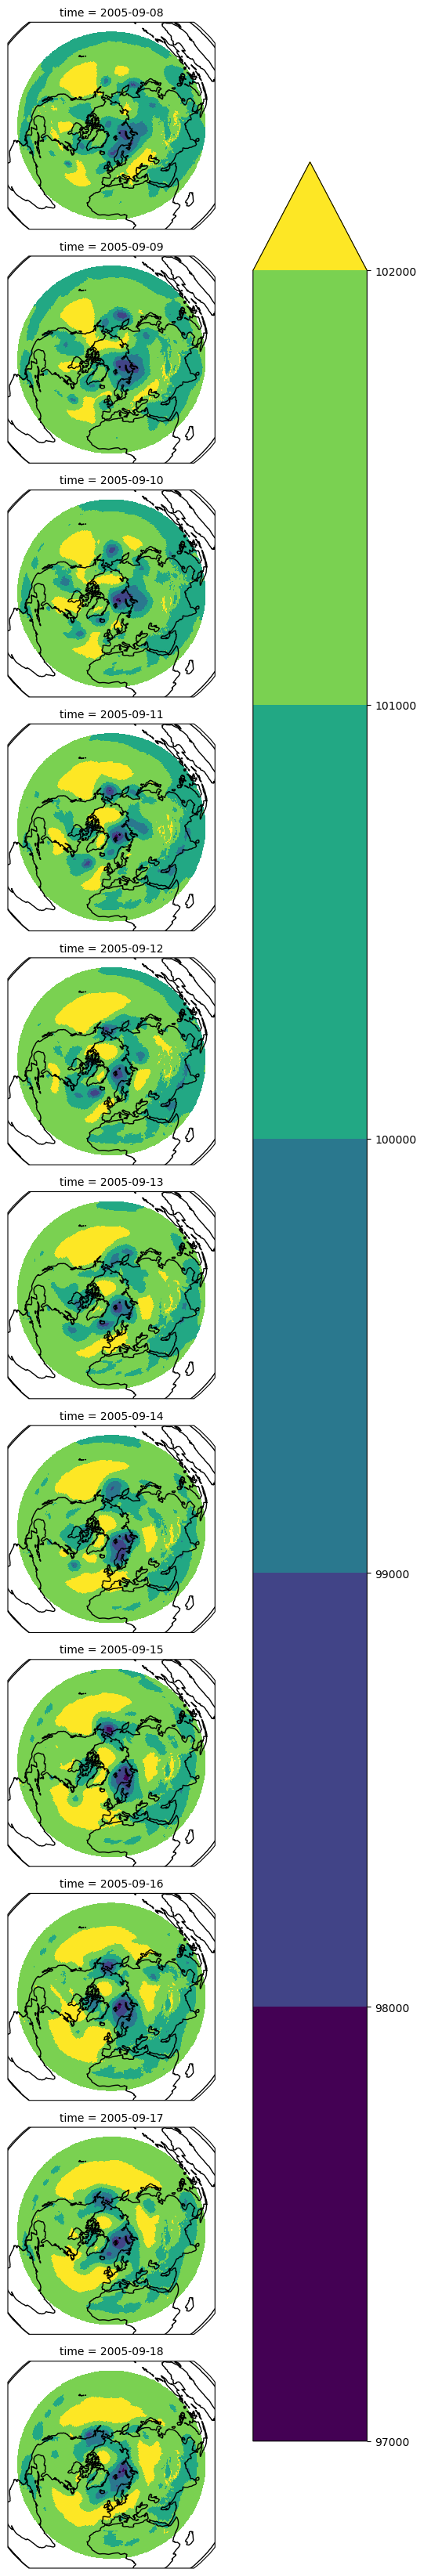

In [24]:
import cartopy.crs as ccrs
plot = ds_variables.sel(var_name='msl').sel(time=slice('2005-09-08','2005-09-18')).plot(row='time', levels=np.arange(97000,103000,1000), subplot_kws=dict(projection=ccrs.LambertAzimuthalEqualArea(0,90)), transform=ccrs.PlateCarree(), aspect=3)
for ax in plot.axs.flatten():
    ax.coastlines()

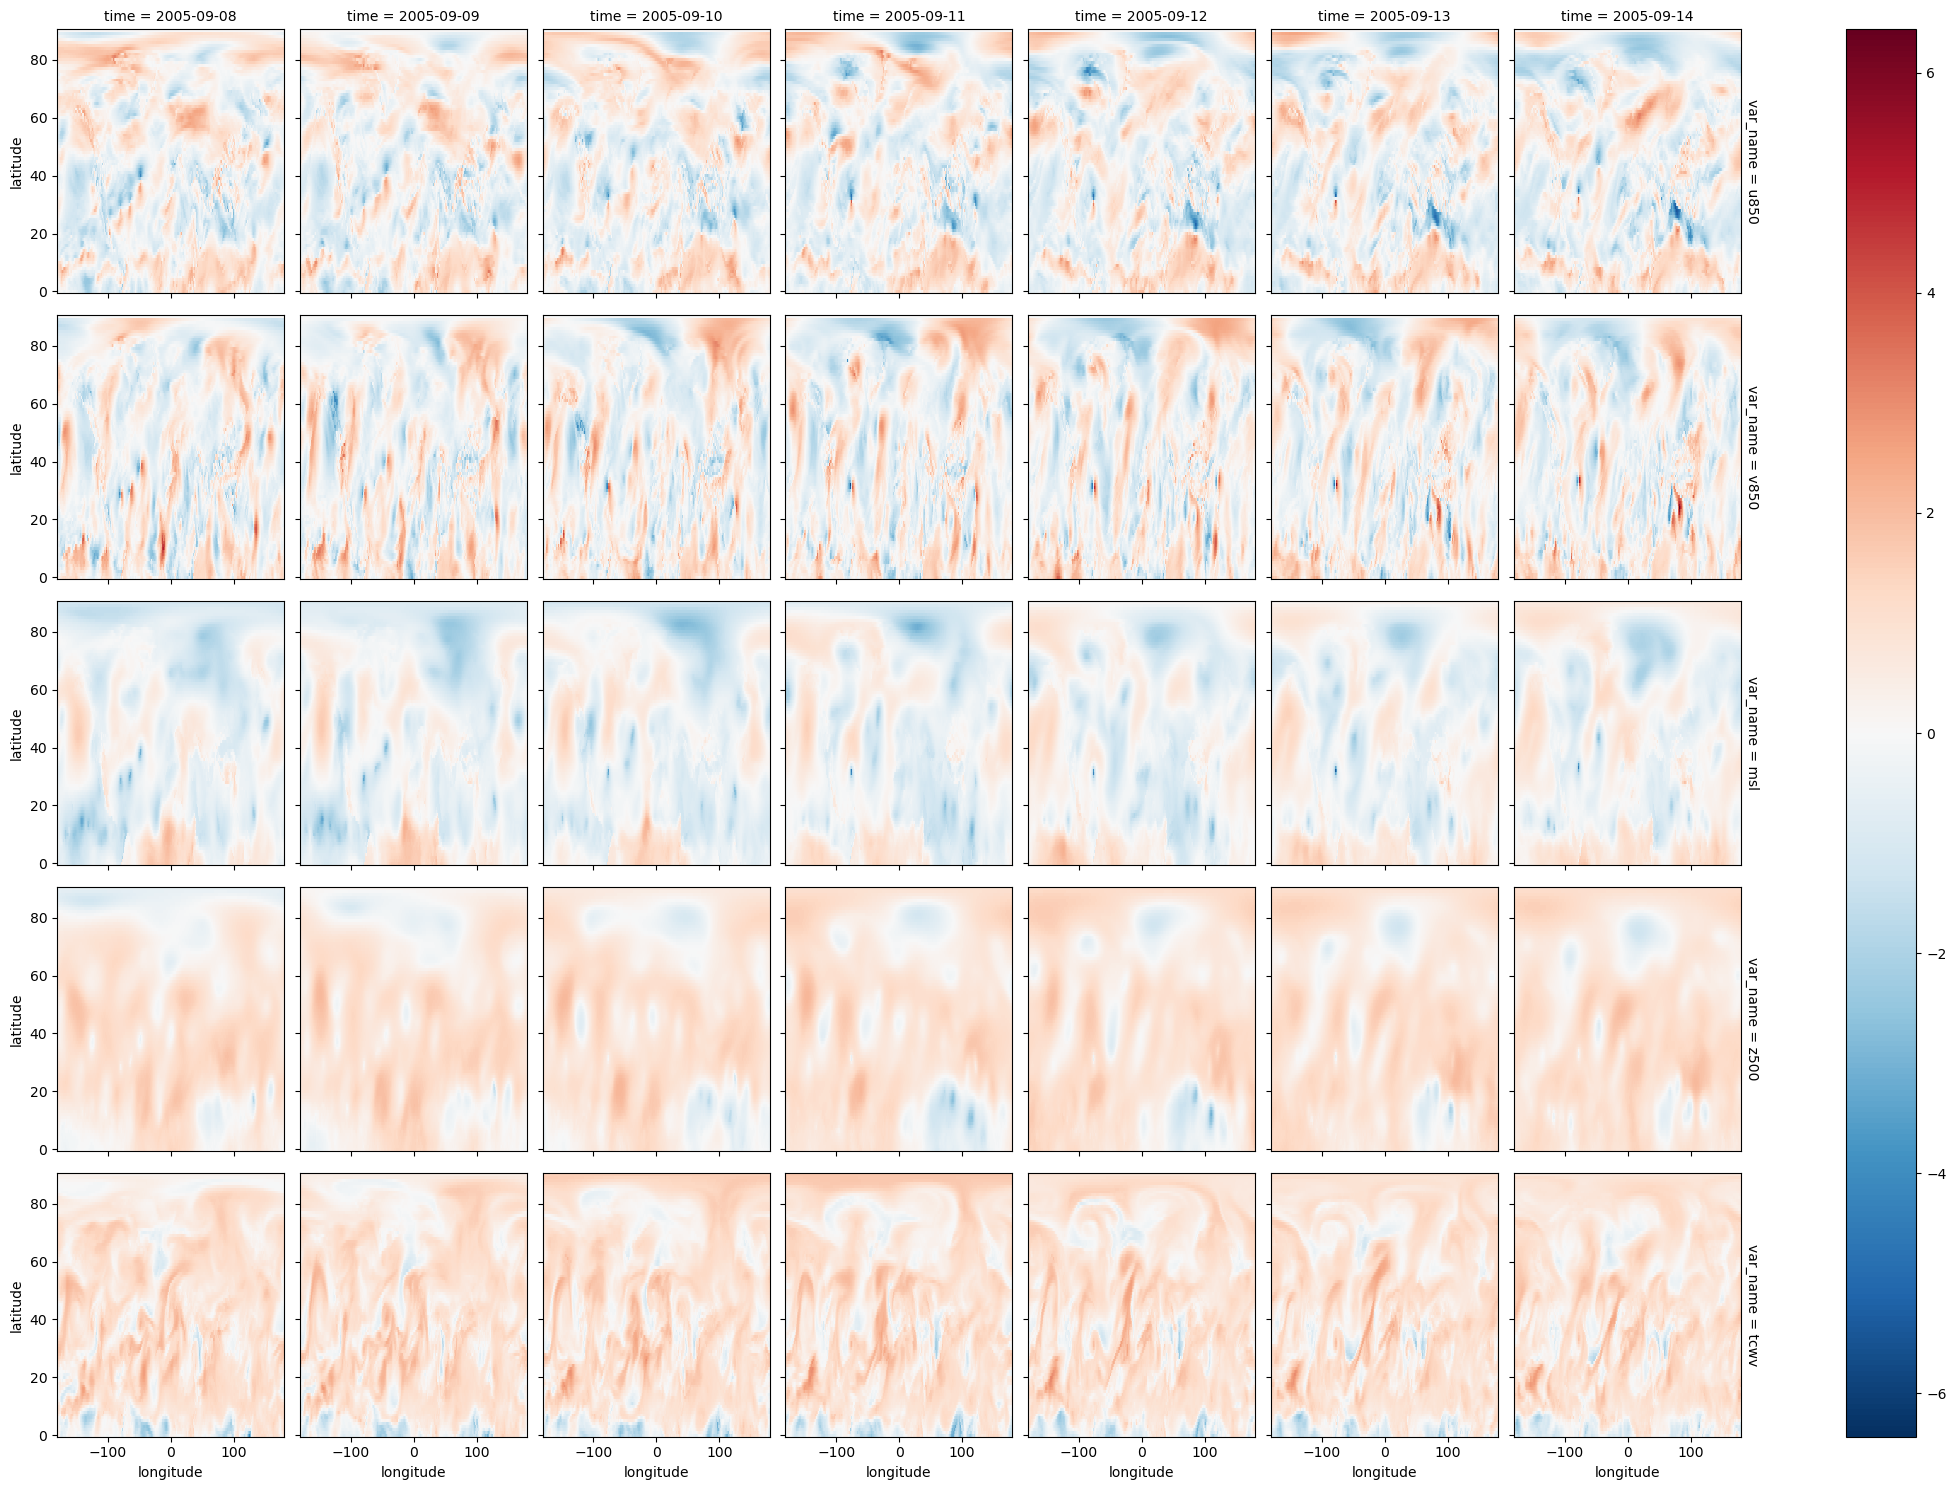

In [12]:
ds_normed.sel(time=slice('2005-09-08','2005-09-14')).plot(col='time', row='var_name')

In [ ]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.drop_vars('dayofyear').chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

In [2]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"
ds = xr.open_zarr(zarr_out)

In [13]:
ds.data_normed.count('time').to_series().value_counts()

data_normed
31289    163800
Name: count, dtype: int64

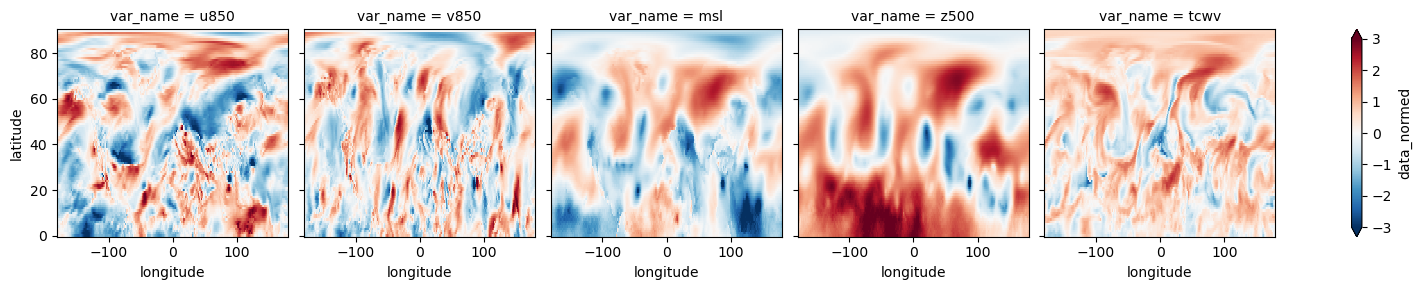

In [10]:
ds.data_normed.isel(time=-350).plot(col='var_name', vmax=3)

In [6]:
dayofyearclim_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + ds.dayofyear_mean
dayofyearstd_timeseries = (ds.time-ds.time).astype(np.float16).groupby(ds.time.dt.dayofyear) + ds.dayofyear_std

In [8]:
ds_normed = (ds_variables - dayofyearclim_timeseries)/(dayofyearstd_timeseries +.1)

In [ ]:
ds_normed

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 21GB
dask.array<truediv, shape=(5, 31289, 91, 360), dtype=float32, chunksize=(1, 91, 23, 90), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'

In [12]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.drop_vars('dayofyear').chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 22.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
# import zarr

# store = zarr.open(zarr_out, mode="a")
# # root = zarr.group(store=store)
# # print("Before deletion:", list(root.keys()))
# del store["mean_fields"]
# del store["std_fields"]
# del store["dayofyear"]
# del store["data_normed"]
# for k in store.keys():
#     print(k)

u850
latitude
time
longitude
z500
msl
tcwv
v850
var_name


In [25]:
ds = xr.open_zarr(zarr_out)
ds

<xarray.Dataset> Size: 21GB
Dimensions:    (time: 31289, latitude: 91, longitude: 360, var_name: 5)
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
Data variables:
    u850       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    z500       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    tcwv       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    v850       (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>

In [26]:
chunks = {'dayofyear': 366, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'dayofyear_mean': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}
enc = {'dayofyear_std': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_out.astype(np.float32).to_zarr(
        zarr_out, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [16]:
ds_normed = (ds_variables - dayofyearclim_timeseries)/(dayofyearstd_timeseries +0.1)

In [17]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 38.19 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-09 18:13:41,272 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f6f48b0f710>>, <Task finished name='Task-4' coro=<Worker.ha

KilledWorker: Attempted to run task ('array-5fcac772b4788877d6947c206126a4f4', 0, 0, 0, 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:36243. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

2025-09-09 18:13:43,287 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,287 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,688 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,736 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-09-09 18:13:43,742 - distributed.nanny - ERROR - Worker process died unexpectedly


In [11]:
ds_normed = (ds_variables.groupby('dayofyear') - dayofyearclim)#.groupby('dayofyear')/dayofyearstd

ValueError: Please pass `labels` to UniqueGrouper when grouping by a chunked array.

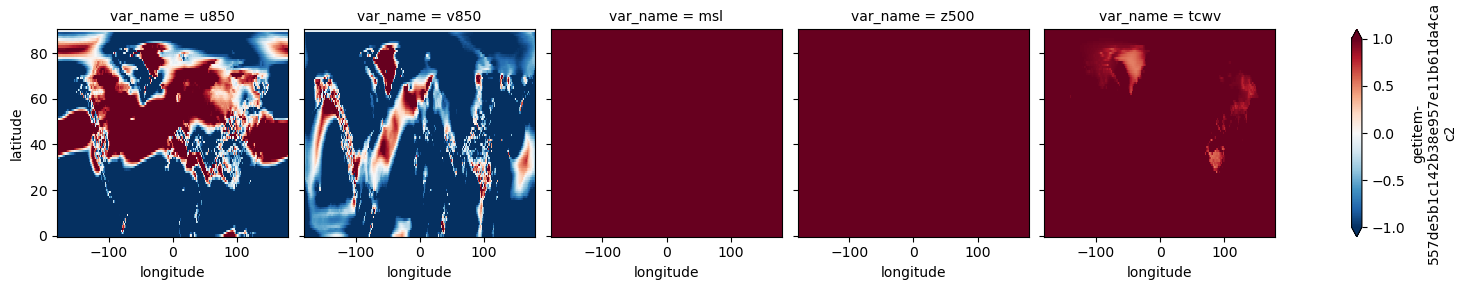

In [33]:
dayofyearclim.min('dayofyear').plot(col='var_name', vmax=1)

In [11]:
dayofyearstd_timeseries.count('time').min().values

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))


array(30522)

In [ ]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"


input_variables = ["u850","v850","msl","z500","tcwv"]

ds_atm = xr.open_zarr(zarr_out)
# ds_mean = ds_atm.mean_fields.sel(var_name = input_variables)
# ds_std = ds_atm.std_fields.sel(var_name = input_variables)
# ds_atm = ds_atm[input_variables].to_array('var_name')
# ds_atm = (ds_atm-ds_mean)/ds_std
ds_atm = ds_atm.data_normed.sel(var_name =input_variables )
ds_atm = ds_atm.transpose('time','var_name','latitude','longitude')

lon_min, lon_max, lat_min, lat_max = [-128, 53, 0, 88]
if ds_atm.latitude.diff('latitude')[0]<0:
    lat_min, lat_max = lat_max, lat_min
ds_atm = ds_atm.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))


In [13]:
ds_atm.isnull().max().values

array(False)

In [5]:
ds_test = ds.sel(longitude=20, latitude=20).load()

In [21]:
df = ds_test[['v850','u850','tcwv','z500','msl']].to_dataframe()

<Axes: ylabel='Frequency'>

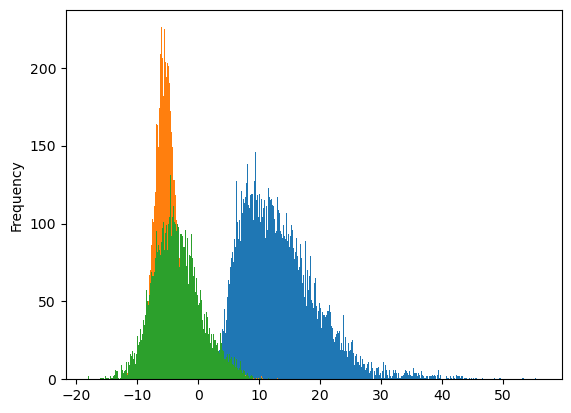

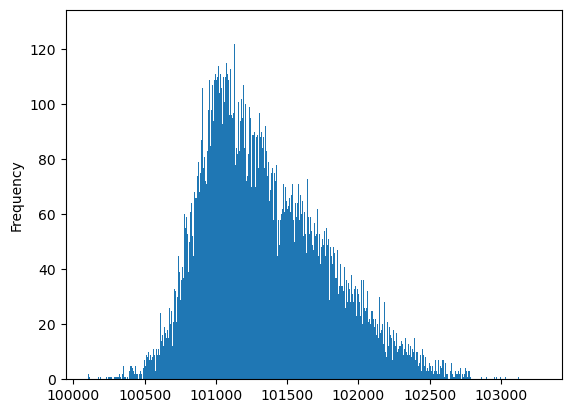

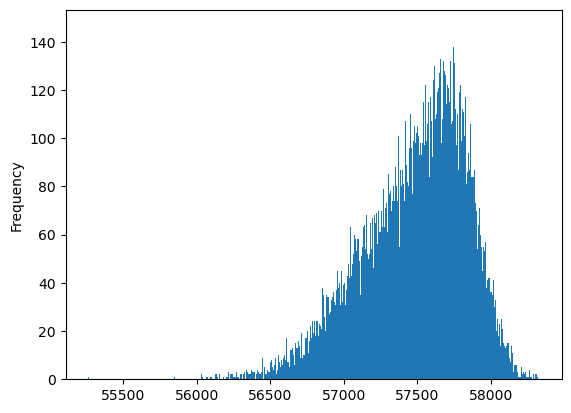

In [26]:
df.tcwv.plot.hist(bins=1000)
df.u850.plot.hist(bins=1000)
df.v850.plot.hist(bins=1000)
plt.figure()
df.msl.plot.hist(bins=1000)

plt.figure()
df.z500.plot.hist(bins=1000)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/flox/aggregations.py:355: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(_var_finalize(sumsq, sum_, count, ddof))
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


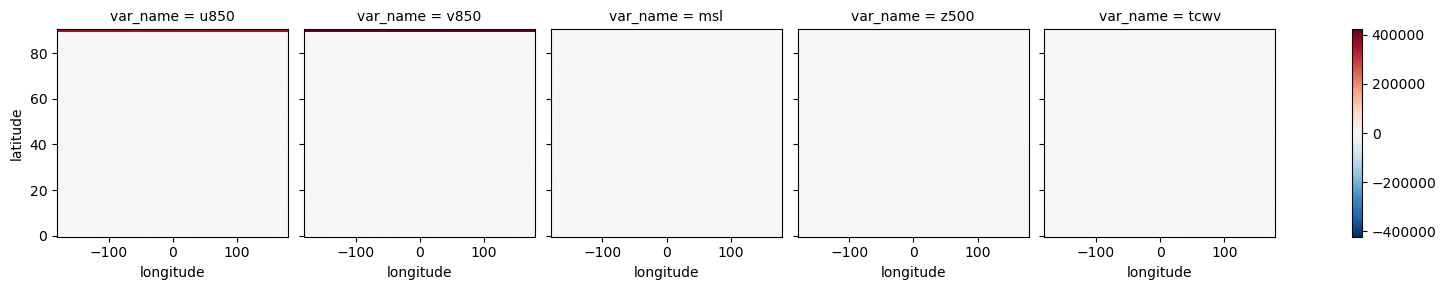

In [38]:
ds_normed.isel(time=-1).plot(col='var_name')

In [5]:
ds_normed

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 21GB
dask.array<truediv, shape=(5, 31289, 91, 360), dtype=float32, chunksize=(1, 256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    dayofyear  (time) int64 250kB 1 2 3 4 5 6 7 ... 236 237 238 239 240 241 242
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'

In [7]:
chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")
enc = {'data_normed': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}

ds_normed.chunk(dict(time=256)).rename('data_normed').astype(np.float32).to_zarr(
        zarr_out, mode='a', #encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 19.09 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-09-09 17:42:22,964 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back

OSError: [Errno 28] No space left on device

2025-09-09 17:43:30,455 - distributed.worker - ERROR - Exception during execution of task ('groupby_nanmean-simple-reduce-partial-d80ed9ff0bc3253a9aaade22c8ba3131', 3, 0, 0, 7)
Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zict/buffer.py", line 184, in __getitem__
    return self.fast[key]
           ~~~~~~~~~^^^^^
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zict/lru.py", line 117, in __getitem__
    result = self.d[key]
             ~~~~~~^^^^^
KeyError: ('groupby_nanmean-chunk-0fa1d0a7229d282cfee019bf5fe78bbd', 3, 0, 0, 29)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib

In [30]:
dayofyearclim_timeseries

<xarray.DataArray (time: 31289, var_name: 5, latitude: 91, longitude: 360)> Size: 21GB
dask.array<add, shape=(31289, 5, 91, 360), dtype=float32, chunksize=(366, 1, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
    dayofyear  (time) int64 250kB 1 2 3 4 5 6 7 ... 236 237 238 239 240 241 242

In [11]:
ds.v850

<xarray.DataArray 'v850' (time: 31289, latitude: 91, longitude: 360)> Size: 4GB
dask.array<open_dataset-v850, shape=(31289, 91, 360), dtype=float32, chunksize=(256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0

In [9]:
ds_normed

<xarray.DataArray (var_name: 5, time: 31289, latitude: 91, longitude: 360)> Size: 41GB
dask.array<truediv, shape=(5, 31289, 91, 360), dtype=float64, chunksize=(1, 256, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'msl' 'z500' 'tcwv'
    dayofyear  (time) int64 250kB 1 2 3 4 5 6 7 ... 236 237 238 239 240 241 242

(array([3.37022300e+06, 4.48650580e+07, 9.22162580e+07, 9.50291880e+07,
        1.18269304e+08, 1.58937144e+08, 1.60014994e+08, 1.44555199e+08,
        1.76030815e+08, 3.17394570e+07]),
 array([0.06474587, 0.50524163, 0.94573742, 1.38623333, 1.82672906,
        2.26722479, 2.70772076, 3.14821649, 3.58871222, 4.02920771,
        4.46970367]),
 <BarContainer object of 10 artists>)

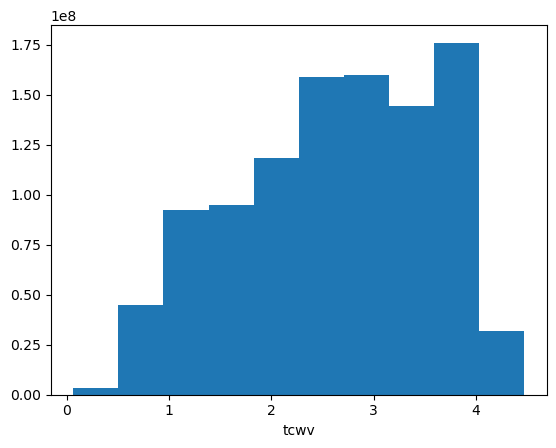

In [5]:
ds_variables.tcwv.plot.hist()

In [ ]:
dayofyearclim = u850_test.rolling(time=30,center=True).mean().groupby('time.dayofyear').mean()
dayofyearclim_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + dayofyearclim

dayofyearstd = u850_test.rolling(time=30,center=True).mean().groupby('time.dayofyear').std()
dayofyearstd_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + dayofyearstd


NameError: name 'u850_test' is not defined

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 6.000e+00, 6.000e+00,
        1.300e+01, 1.400e+01, 1.800e+01, 2.300e+01, 3.200e+01, 5.900e+01,
        8.000e+01, 1.110e+02, 1.590e+02, 2.120e+02, 2.830e+02, 4.140e+02,
        4.920e+02, 7.040e+02, 8.940e+02, 1.098e+03, 1.452e+03, 1.628e+03,
        1.851e+03, 2.032e+03, 2.077e+03, 2.020e+03, 2.049e+03, 1.859e+03,
        1.624e+03, 1.396e+03, 1.203e+03, 1.054e+03, 8.710e+02, 7.480e+02,
        6.070e+02, 5.390e+02, 4.160e+02, 3.880e+02, 3.600e+02, 2.640e+02,
        2.260e+02, 2.260e+02, 1.900e+02, 1.900e+02, 1.530e+02, 1.340e+02,
        1.160e+02, 1.360e+02, 9.900e+01, 9.400e+01, 7.600e+01, 6.700e+01,
        6.300e+01, 6.100e+01, 5.000e+01, 3.700e+01, 3.900e+01, 2.800e+01,
        2.500e+01, 3.100e+01, 2.000e+01, 2.400e+01, 1.900e+01, 1.700e+01,
        2.300e+01, 6.000e+00, 1.000e+01, 1.100e+01, 7.000e+00, 7.000e+00,
        7.000e+00, 3.000e+00, 7.000e+0

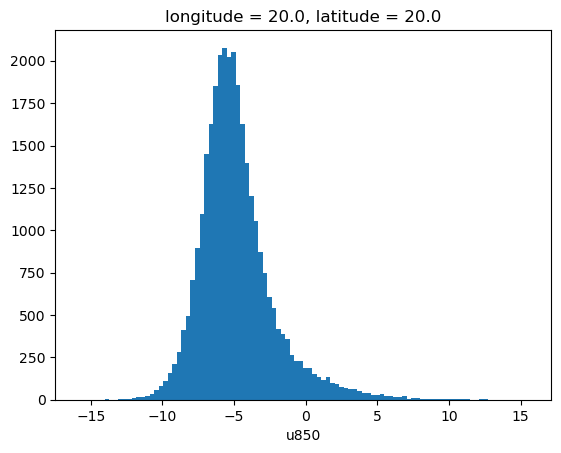

In [55]:
u850_test.plot.hist(bins=100)

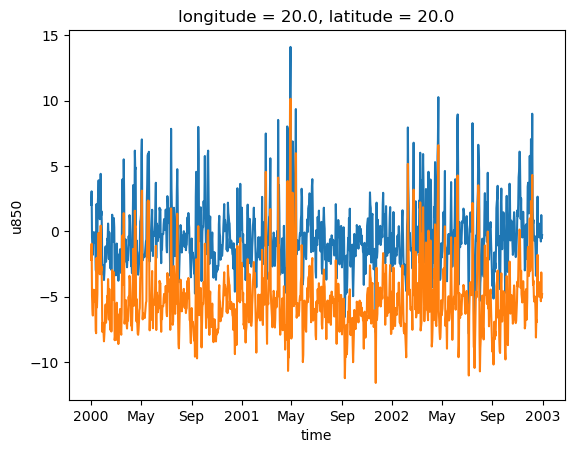

In [52]:
# ((u850_test-dayofyearclim_timeseries)/dayofyearstd_timeseries).sel(time=slice('2000','2001')).plot()
u_norm = ((u850_test-dayofyearclim_timeseries)/dayofyearstd_timeseries)

u_norm.sel(time=slice('2000','2002')).plot()
u850_test.sel(time=slice('2000','2002')).plot()

# dayofyearclim_timeseries.sel(time=slice('2000','2001')).plot(color='purple')
# dayofyearstd_timeseries.sel(time=slice('2000','2001')).plot(color='purple')


In [37]:
u850_clim = ds.u850.groupby(ds.time.dt.dayofyear).mean().compute()
u850_clim = (xr.concat([u850_clim.assign_coords(dayofyear=u850_clim.dayofyear-366),
           u850_clim,
           u850_clim.assign_coords(dayofyear=u850_clim.dayofyear+366),], dim='dayofyear').rolling(dayofyear=30, center=True).mean()
    .sel(dayofyear=np.arange(1,367))
)

u850_std = ds.u850.groupby(ds.time.dt.dayofyear).std().compute()
u850_std = (xr.concat([u850_std.assign_coords(dayofyear=u850_std.dayofyear-366),
           u850_std,
           u850_std.assign_coords(dayofyear=u850_std.dayofyear+366),], dim='dayofyear').rolling(dayofyear=30, center=True).mean()
    .sel(dayofyear=np.arange(1,367))
)

In [38]:
u850_clim_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + u850_clim

u850_std_timeseries = (ds.time-ds.time).astype(float).groupby(ds.time.dt.dayofyear) + u850_std

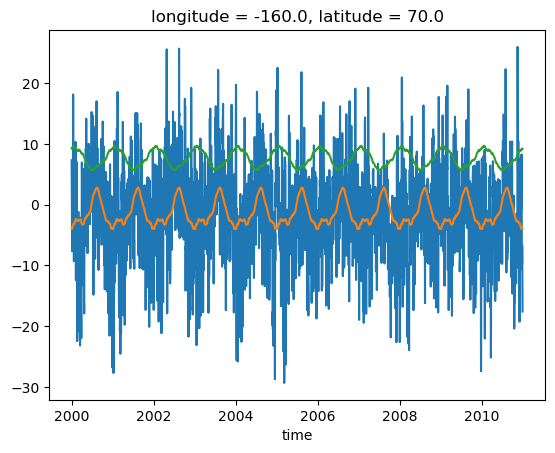

In [ ]:
ds.u850.isel(longitude=20, latitude=20).sel(time=slice('2000','2010')).plot()
u850_clim_timeseries.isel(longitude=20, latitude=20).sel(time=slice('2000','2010')).plot()
u850_clim_timeseries.isel(longitude=20, latitude=20).sel(time=slice('2000','2010')).plot()




In [ ]:
u850_norm = (ds.u850.isel(longitude=20, latitude=20) - u850_clim_timeseries.isel(longitude=20, latitude=20) )/u850_std_timeseries.isel(longitude=20, latitude=20) 
u850_norm.plot()


In [32]:
u850_clim

<xarray.DataArray 'u850' (dayofyear: 366, latitude: 91, longitude: 360)> Size: 48MB
array([[[ 1.9384865e-06,  1.9384865e-06,  1.9384865e-06, ...,
          1.9384865e-06,  1.9384865e-06,  1.9384865e-06],
        [ 3.1554263e+00,  3.1595283e+00,  3.1609359e+00, ...,
          3.1291299e+00,  3.1399581e+00,  3.1488085e+00],
        [ 3.2171385e+00,  3.2162206e+00,  3.2135944e+00, ...,
          3.2108912e+00,  3.2143621e+00,  3.2164881e+00],
        ...,
        [-6.1354580e+00, -6.3186903e+00, -6.5102510e+00, ...,
         -5.5550876e+00, -5.7531958e+00, -5.9469919e+00],
        [-5.6765432e+00, -5.9046578e+00, -6.1334491e+00, ...,
         -4.9610529e+00, -5.1923432e+00, -5.4236126e+00],
        [-5.0670886e+00, -5.3377218e+00, -5.6029816e+00, ...,
         -4.2475753e+00, -4.5138669e+00, -4.7772317e+00]],

       [[ 1.0625253e-06,  1.0625253e-06,  1.0625253e-06, ...,
          1.0625253e-06,  1.0625253e-06,  1.0625253e-06],
        [ 3.1441345e+00,  3.1482852e+00,  3.1497688e+00, ...,
          3.1178455e+00,  3.1286466e+00,  3.1374924e+00],
        [ 3.1905761e+00,  3.1895094e+00,  3.1867826e+00, ...,
          3.1849504e+00,  3.1881950e+00,  3.1901104e+00],
...
         -5.5101838e+00, -5.7177510e+00, -5.9166169e+00],
        [-5.6584263e+00, -5.8899989e+00, -6.1178942e+00, ...,
         -4.9305296e+00, -5.1676731e+00, -5.4021745e+00],
        [-5.0625496e+00, -5.3359137e+00, -5.5975428e+00, ...,
         -4.2467370e+00, -4.5152087e+00, -4.7751098e+00]],

       [[ 1.9423298e-06,  1.9423298e-06,  1.9423298e-06, ...,
          1.9423298e-06,  1.9423298e-06,  1.9423298e-06],
        [ 3.1400230e+00,  3.1443622e+00,  3.1459980e+00, ...,
          3.1129401e+00,  3.1240442e+00,  3.1331580e+00],
        [ 3.2096651e+00,  3.2092605e+00,  3.2071292e+00, ...,
          3.2018485e+00,  3.2058377e+00,  3.2084918e+00],
        ...,
        [-6.1399951e+00, -6.3240867e+00, -6.5131173e+00, ...,
         -5.5477242e+00, -5.7492685e+00, -5.9464145e+00],
        [-5.6831670e+00, -5.9124961e+00, -6.1409340e+00, ...,
         -4.9654980e+00, -5.1977711e+00, -5.4278884e+00],
        [-5.0829706e+00, -5.3533745e+00, -5.6172366e+00, ...,
         -4.2631474e+00, -4.5305448e+00, -4.7934813e+00]]],
      shape=(366, 91, 360), dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Attributes:
    regrid_method:  bilinear

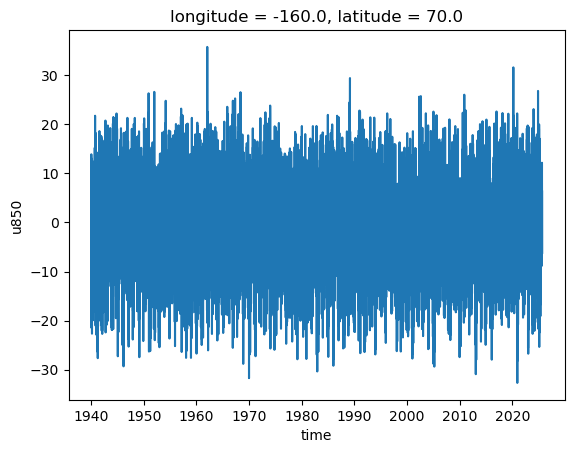

In [31]:
ds.u850.isel(latitude=20, longitude=20).plot()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 55.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


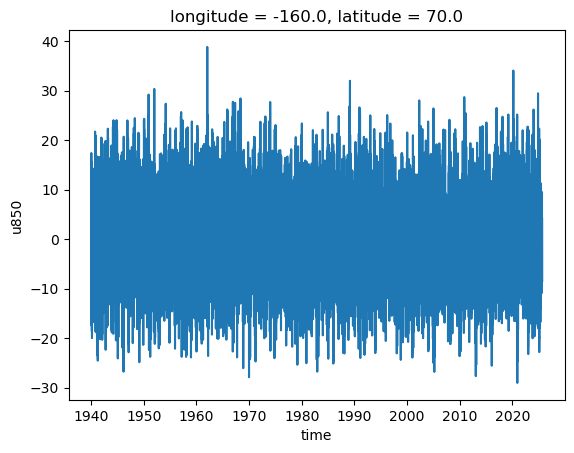

In [30]:
(ds.u850.groupby(ds.time.dt.dayofyear) - u850_clim ).isel(latitude=20, longitude=20).plot()

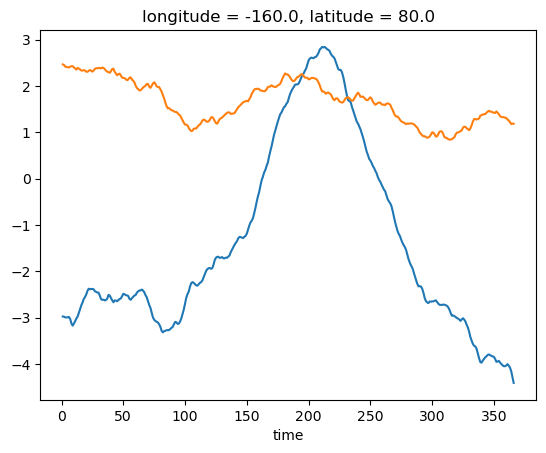

In [15]:
u850_clim.isel(latitude=20, longitude=20).rename(dayofyear='time').lntime.filter('moving_average', cutoff=30).plot()
u850_clim.isel(latitude=10, longitude=20).rename(dayofyear='time').lntime.filter('moving_average', cutoff=30).plot()